# Import and eval functions

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, h5py, gc, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = "./"
proj = Path(REPO_ROOT).resolve()

# allow: import ADCNN.*
sys.path.insert(0, str(proj))
# allow: import utils.*  (where utils == ADCNN/utils)
sys.path.insert(0, str(proj / "ADCNN"))

import ADCNN.evaluation.detection as evals

# Diffim (v7) inference path.
from ADCNN.inference.predict import (
    predict_panel_overlap_3ch,
    predict_panel_overlap_3ch_full,
)
from ADCNN.inference.rf_postproc import (
    compute_v2_features, apply_rf_v2, materialize_label_mask_v2,
    rf_score_sweep, load_rf, save_rf, build_rf_postproc_v2,
    DEFAULT_THR as RF_V2_DEFAULT_THR,
)
from ADCNN.evaluation.parameter_recovery import (
    evaluate_parameter_recovery, summarize_residuals, plot_residuals,
)

# Canonical model: v7 TorchScript (self-contained, no class definition needed).
# Prefer the promoted in-repo checkpoint — the hard-neg fine-tuned v7 + the
# real-residual-hardened RF (see ADCNN/scripts/test_real/REPRODUCE.md;
# revert with restore.sh). Falls back to a user-provisioned ./checkpoints/.
# RF_V2_DEFAULT_THR follows ADCNN.inference.rf_postproc.DEFAULT_THR
# (0.50 for the promoted pipeline — threshold-flat, lower FP).
_PROMOTED = "./models/v7_diffim_scripted.pt"
MODEL_CKPT = _PROMOTED if Path(_PROMOTED).exists() else "./checkpoints/v7_scripted.pt"
# LEAK-FREE stage-2 RF: trained on the 50 held-out val panels of train.h5
# (v7 never trained on them), NOT on test_5sigma. The previously-shipped
# rf_postproc_v2.pkl was trained on test_5sigma = evaluation leakage; see
# experiments/explore_rf_leakage/ (train_eval_rf_valpanels.py).
RF_V2_CKPT = "./models/rf_postproc.pkl"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"MODEL_CKPT        = {MODEL_CKPT}")
print(f"RF_V2_CKPT        = {RF_V2_CKPT}")
print(f"RF_V2_DEFAULT_THR = {RF_V2_DEFAULT_THR}  (ADCNN rf_postproc.DEFAULT_THR)")

# --- Operating point: CHOSEN IN ADVANCE, never tuned on the test set ---
# The stage-2 RF score cut is a fixed constant set during model preparation
# (ADCNN.inference.rf_postproc.DEFAULT_THR). The RF-kept label mask is binarised
# at MASK_THR. No threshold is scanned or selected on the test data anywhere below.
RF_THR   = RF_V2_DEFAULT_THR
MASK_THR = 0.5
print(f"RF_THR={RF_THR}  MASK_THR={MASK_THR}  (fixed in advance — no test-set tuning)")

MODEL_CKPT        = ./models/v7_diffim_scripted.pt
RF_V2_CKPT        = ./models/rf_postproc.pkl
RF_V2_DEFAULT_THR = 0.5  (ADCNN rf_postproc.DEFAULT_THR)
RF_THR=0.5  MASK_THR=0.5  (fixed in advance — no test-set tuning)


## Pipeline & reproducibility

This notebook evaluates the **promoted** detector on the synthetic
`test_{5,4,3}sigma` sets: the hard-negative **fine-tuned v7** + the
real-residual-**hardened V2 RF**, operated at `DEFAULT_THR = 0.50` (the
fine-tuned model is threshold-flat, so a high threshold keeps recall while
roughly halving false positives).

* Train v7 / fine-tune: `python -m ADCNN.training.train [--init-from …]`
* Real-data pipeline + how this model was produced/promoted:
  `ADCNN/scripts/test_real/REPRODUCE.md` (revert: `restore.sh`).
* Real-asteroid evaluation: **`Evaluation_Real.ipynb`**.

The headline synthetic result is the **5σ + NN** row (stack ∪ network) vs the
stack alone, plus the objectwise/combined confusion at `best_threshold=0.5`
and the per-detection parameter-recovery residuals. Prereqs:
`DATA_DIFFIM/test_{5,4,3}sigma/{test.h5,test.csv}` and the checkpoints above
(data/ckpts are gitignored by repo convention)."

In [2]:
def calculate_model_metrics(catalog, predictions, ground_truth, stack_fp=None, *, threshold):
    """Report objectwise/pixelwise confusion + completeness at a FIXED, pre-chosen
    operating `threshold`. No threshold is selected here — the operating point is decided
    in advance (RF score cut = rf_postproc.DEFAULT_THR; RF-kept mask binarised at MASK_THR).
    Pure inference/eval: nothing is fit or tuned on the test set."""
    catalog = catalog.copy()
    _, _, catalog = evals.full_confusion(catalog=catalog, ground_truth=ground_truth, predictions=predictions, stack_fp=stack_fp, threshold=threshold, verbose=True)
    _ = evals.combined_confusion_separate(catalog=catalog, ground_truth=ground_truth, predictions=predictions, threshold=threshold, verbose=True, stack_mask=stack_fp)
    _ = evals.plot_detect_hist(catalog, "PSF_mag", bins=12, title="NN detections vs PSF_mag")
    _ = evals.plot_detect_hist(catalog, "trail_length", bins=12, title="Detections vs trail length")
    _ = evals.plot_detect_hist(catalog, "SNR", bins=10, title="Detections vs SNR", xlim=[0, 10], density=True)
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, title="Model completeness")
    _ = evals.plot_completeness_2d(catalog, snr_bins=10, trail_bins=10, detected=(~catalog["stack_detection"].values.astype(bool) & catalog["nn_detected"].values.astype(bool)), title="Model detection but not stack detection")
    plt.show()
    return catalog

def get_stack_metrics(catalog, fp_mask):
    tp = (catalog["stack_detection"]==True).sum()
    fn = (catalog["stack_detection"]==False).sum()
    fp = fp_mask.max(axis=(1, 2)).sum()
    return  {"TP": tp, "FP": fp, "FN": fn, "TN": pd.NA}

def load_model(ckpt_path):
    """Load v7 TorchScript model from disk. Returns the scripted module on DEVICE."""
    m = torch.jit.load(str(ckpt_path), map_location=DEVICE)
    m.eval()
    print(f"Loaded model from: {ckpt_path}")
    return m

def predict_panels_v7(test_h5, model, device=DEVICE, tile=128, stride=64) -> np.ndarray:
    """Run v7 sliding-window inference on every panel in `test_h5`.

    Returns an (N, H, W) float32 probability array (seg-logits sigmoid only).
    Use `predict_panels_v7_full` when the orient / line-aggregator heads are
    also needed (e.g. for the V2 RF postprocessing).
    """
    out = []
    with h5py.File(test_h5, "r") as f:
        N = int(f["images"].shape[0])
        for pid in range(N):
            img = f["images"][pid][:]
            rl  = f["real_labels"][pid][:]
            p = predict_panel_overlap_3ch(model, img, rl, device=device, tile=tile, stride=stride)
            out.append(p.astype(np.float32))
    return np.stack(out, axis=0)


def predict_panels_v7_full(test_h5, model, device=DEVICE, tile=128, stride=64):
    """Sliding-window inference returning all four maps per panel.

    Returns (prob, orient_sin, orient_cos, agg) — each (N, H, W). `prob` is
    float32 (sigmoid of seg_logits); the auxiliary heads are float16 to keep
    memory manageable. `prob` is the same value the legacy `predict_panels_v7`
    produces, so downstream metric cells continue to work unchanged.
    """
    probs, sins, coss, aggs = [], [], [], []
    with h5py.File(test_h5, "r") as f:
        N = int(f["images"].shape[0])
        for pid in range(N):
            img = f["images"][pid][:]
            rl  = f["real_labels"][pid][:]
            p, s, c, a = predict_panel_overlap_3ch_full(
                model, img, rl, device=device, tile=tile, stride=stride,
            )
            probs.append(p.astype(np.float32))
            sins.append(s); coss.append(c); aggs.append(a)
    return (np.stack(probs, axis=0),
            np.stack(sins,  axis=0),
            np.stack(coss,  axis=0),
            np.stack(aggs,  axis=0))


# --- Current (v7-era) postprocessing ---------------------------------------
from ADCNN.inference.candidates import extract_candidates, CandidateExtractorConfig
from ADCNN.inference.matched_filter import (
    panel_mad_sigma, matched_filter_for_nn_candidates,
)
from ADCNN.evaluation.detection import objectwise_confusion
from scipy import ndimage as ndi

def diffim_label_mask(predictions, *, adaptive=True, t_low=0.05, min_area=4):
    """Per-panel candidate extraction (v7 pipeline) — no matched-filter cut.

    Returns an (N, H, W) int32 label mask. Same connectivity / area filter as
    `extract_candidates`. Use this when you don't have the raw diffim handy.
    """
    N = predictions.shape[0]
    out = np.zeros(predictions.shape, dtype=np.int32)
    cfg = CandidateExtractorConfig(t_low=t_low, min_area=min_area, adaptive_t_low=adaptive)
    structure = ndi.generate_binary_structure(2, 2)
    for pid in range(N):
        panel = predictions[pid].astype(np.float32)
        cand = extract_candidates(panel, cfg=cfg, panel_id=pid)
        if len(cand) == 0:
            continue
        effective_t = float(cand["effective_t_low"].iloc[0])
        labels, n_lab = ndi.label(panel > effective_t, structure=structure)
        keep = np.zeros(n_lab + 1, dtype=bool)
        keep[cand["candidate_id"].astype(int).to_numpy()] = True
        out[pid] = labels * keep[labels]
    return out

def lsst_post_metrics(catalog, gt_test, stack_fp, *, min_area=4):
    """Run the same diffim postprocessing on the LSST stack footprints."""
    lsst_bin = (stack_fp > 0).astype(np.float32)
    masks_lsst = diffim_label_mask(lsst_bin, adaptive=False, t_low=0.5, min_area=min_area)
    (otp, ofp, ofn), _, _ = evals.full_confusion(
        catalog=catalog, ground_truth=gt_test, predictions=masks_lsst,
        stack_fp=None, threshold=0.5, verbose=False,
    )
    return masks_lsst, {"TP": int(otp), "FP": int(ofp), "FN": int(ofn), "TN": pd.NA}


def rf_v2_sweep_table(cand_df):
    """Score sweep with TP/FP counts (from `rf_score_sweep`)."""
    return rf_score_sweep(cand_df, score_col="score_rf")


def two_stage_v2(prob, orient_sin, orient_cos, orient_agg, diffim_panels, *,
                 stack_fp, rf, rf_thr=RF_V2_DEFAULT_THR, verbose=True):
    """Run V2 two-stage postprocessing.

    Returns (masks, cand_df_scored, sweep_table). `masks` is the (N, H, W)
    int32 label mask kept after score >= `rf_thr` — pass it straight into
    `calculate_model_metrics`. `cand_df_scored` carries the per-candidate
    score (`score_rf` column) so it can be reused for ad-hoc plotting.
    """
    cand_df, panel_probs_dict = compute_v2_features(
        prob, diffim_panels, orient_sin, orient_cos, orient_agg,
        real_labels=stack_fp, verbose=verbose,
    )
    cand_df = apply_rf_v2(cand_df, rf)
    sweep = rf_v2_sweep_table(cand_df)
    if verbose:
        print("V2 RF score sweep (TP/FP per threshold):")
        print(sweep.to_string(index=False))
        print(f"\nUsing rf_thr={rf_thr}:  "
              f"{int((cand_df['score_rf'] >= rf_thr).sum())} candidates kept of {len(cand_df)}")
    masks = materialize_label_mask_v2(
        cand_df[cand_df["score_rf"] >= rf_thr], panel_probs_dict, prob.shape,
    )
    return masks, cand_df, sweep


# --- Legacy MF-only two-stage (kept for backward compatibility) -----------
# The V2 RandomForest pipeline above subsumes this — the legacy helpers
# remain only so older notebooks / scripts that imported them keep working.

def diffim_extract_candidates_mf(
    predictions, diffim_panels,
    *, adaptive=True, t_low=0.05, min_area=4, line_width=2, pad_length=4,
):
    """Run extract_candidates per panel and compute matched-filter SNR.

    Returns (cand_df, panel_probs_dict).  `cand_df` has every column from
    `extract_candidates` plus mf_snr / mf_n_line / mf_flux / mf_length.
    """
    N = predictions.shape[0]
    cfg = CandidateExtractorConfig(t_low=t_low, min_area=min_area, adaptive_t_low=adaptive)
    cand_dfs = []
    panel_probs_dict, diffim_dict, panel_sigmas = {}, {}, {}
    for pid in range(N):
        panel = predictions[pid].astype(np.float32, copy=False)
        cand = extract_candidates(panel, cfg=cfg, panel_id=pid)
        if len(cand):
            cand_dfs.append(cand)
        panel_probs_dict[pid] = panel
        diffim_dict[pid] = diffim_panels[pid]
        panel_sigmas[pid] = panel_mad_sigma(diffim_dict[pid])
    if not cand_dfs:
        return pd.DataFrame(), panel_probs_dict
    cand_df = pd.concat(cand_dfs, ignore_index=True)
    cand_df = matched_filter_for_nn_candidates(
        cand_df, panel_probs=panel_probs_dict, diffim_panels=diffim_dict,
        panel_sigmas=panel_sigmas, line_width=line_width, pad_length=pad_length,
    )
    return cand_df, panel_probs_dict


def materialize_label_mask(cand_df, panel_probs_dict, shape):
    """Build an (N, H, W) int32 label mask from a (possibly filtered) cand_df."""
    return materialize_label_mask_v2(cand_df, panel_probs_dict, shape)


def mf_sweep_table(
    cand_df, panel_probs_dict, shape,
    catalog, stack_fp,
    mf_thresholds=(0, 2, 3, 4, 5, 6, 7, 8, 10),
):
    """Sweep matched-filter SNR threshold; report object-level (TP, FP, FN)."""
    rows = []
    for thr in mf_thresholds:
        sub = cand_df[cand_df["mf_snr"] >= thr]
        masks = materialize_label_mask(sub, panel_probs_dict, shape)
        otp, ofp, ofn, _ = objectwise_confusion(
            catalog=catalog, predictions=masks, threshold=0.5,
            stack_fp=stack_fp,
        )
        rows.append({
            "mf_thr": float(thr),
            "n_candidates": int(len(sub)),
            "TP": int(otp), "FP": int(ofp), "FN": int(ofn),
        })
    return pd.DataFrame(rows)

# Retrain the V2 RF (optional)

The shipped `rf_postproc_v2.pkl` was trained on `test_5sigma` with the same
relabel+train pipeline as `build_rf_postproc_v2`. Re-run the cell below only
if you want to rebuild the classifier on a different dataset or after a
feature-set change. Otherwise skip it — the two-stage cells load the
existing pickle.

# 5 sigma threshold

In [3]:
test_h5  = "./DATA_DIFFIM/test_5sigma/test.h5"
test_csv = "./DATA_DIFFIM/test_5sigma/test.csv"

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test  = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Panels:", gt_test.shape[0], "  panel shape:", gt_test.shape[1:])

Panels: 50   panel shape: (4004, 4096)


## LSST stack

Object-wise Confusion Matrix (raw stack footprints)
F1 Score: 0.1206, F2 Score: 0.2183
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                6405
Actual Positive                 525                 475



Object-wise Confusion Matrix (stack + same postprocessing as NN)
F1 Score: 0.0008, F2 Score: 0.0015
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                6241
Actual Positive                 997                   3



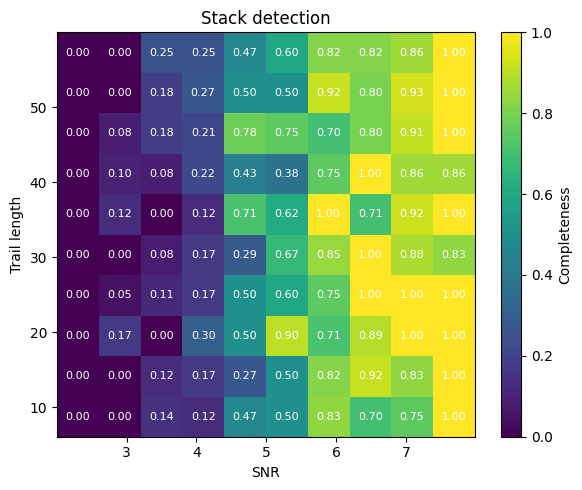

In [4]:
evals.print_confusion_matrix(get_stack_metrics(test_catalog, stack_fp), title="Object-wise Confusion Matrix (raw stack footprints)")

_, lsst_pp_cm = lsst_post_metrics(test_catalog, gt_test, stack_fp)
evals.print_confusion_matrix(lsst_pp_cm, title="Object-wise Confusion Matrix (stack + same postprocessing as NN)")

_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

## Model

In [5]:
model = load_model(MODEL_CKPT)
# Capture seg + orient + line-aggregator heads in a single pass so the V2
# two-stage cell below doesn't need to re-run inference.
p, p_sin, p_cos, p_agg = predict_panels_v7_full(test_h5, model)
del model
gc.collect(); torch.cuda.empty_cache()
print("Predictions shape:", p.shape, " aux shapes:", p_sin.shape, p_cos.shape, p_agg.shape)

Loaded model from: ./models/v7_diffim_scripted.pt


Predictions shape: (50, 4004, 4096)  aux shapes: (50, 4004, 4096) (50, 4004, 4096) (50, 4004, 4096)


### Two stage classifier

  [v2] matched_filter   19.9s


  [v2] long_mf L= 30  18.2s


  [v2] long_mf L= 60  18.8s


  [v2] long_mf L= 90  19.4s


  [v2] long_mf L=120  20.3s


...

  [v2] low-thr PCA     68.5s


  [v2] orient          35.7s


V2 RF score sweep (TP/FP per threshold):
  thr  n_candidates
0.020         97949
0.025         93193
0.030         88776
0.035         84607
0.040         80665
0.045         76891
0.050         73405
0.055         70043
0.060         66877
0.065         63943
0.070         61118
0.075         58423
0.080         55921
0.085         53447
0.090         51189
0.095         49044
0.100         46952
0.120         39199
0.140         32658
0.160         27092
0.180         22614
0.200         18940
0.220         16136
0.240         14012
0.260         12317
0.280         10955
0.300          9873
0.320          8935
0.340          8122
0.360          7466
0.380          6861
0.400          6286
0.420          5803
0.440          5395
0.460          5011
0.480          4626

Using rf_thr=0.5:  4297 candidates kept of 113336


Object-level Confusion Matrix
F1 Score: 0.2835, F2 Score: 0.4472
                 Predicted Negative  Predicted Positive
Actual Negative                   0                3402
Actual Positive                 273                 727

Pixel-level Confusion Matrix
F1 Score: 0.2001, F2 Score: 0.3492
                 Predicted Negative  Predicted Positive
Actual Negative           813620703             5373614
Actual Positive              313538              711345



Combined Object-level Confusion Matrix
F1 Score: 0.1283, F2 Score: 0.2547
                 Predicted Negative  Predicted Positive
Actual Negative                   0                9807
Actual Positive                 259                 741



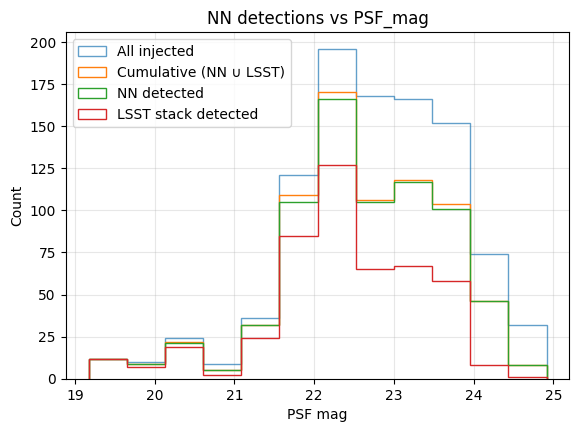

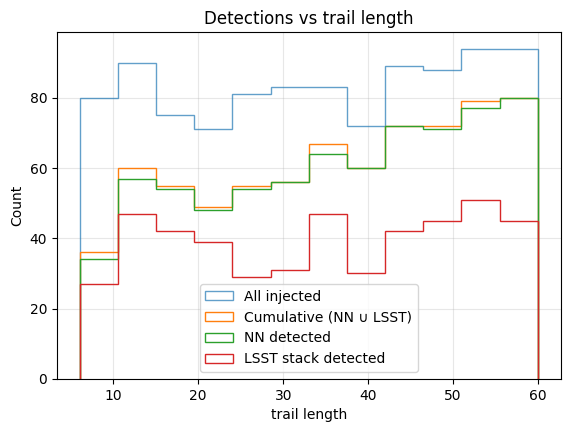

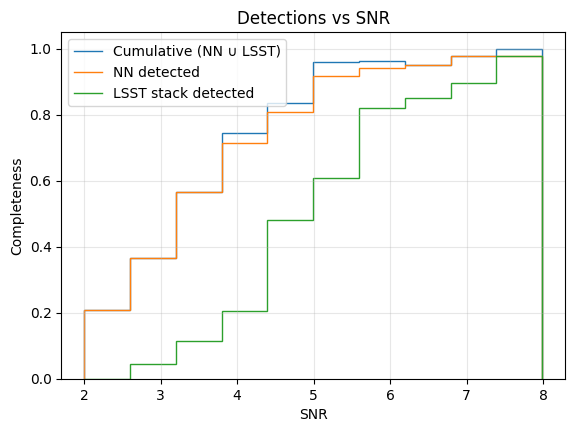

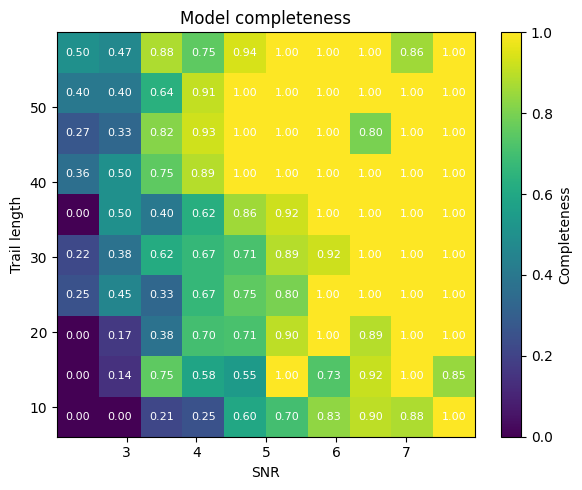

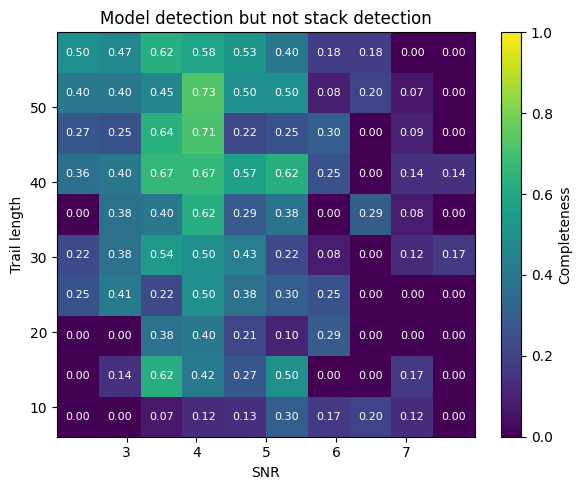

32019

In [6]:
# Stage 2 = RandomForest reranker over a 72-feature view of each NN candidate:
# diffim morphology + matched-filter (PCA & fixed-length & multi-angle) +
# low-threshold PCA + orient-aware MF + line-aggregator confidence. The RF was
# trained panel-disjoint on test_5sigma; at rf_thr=0.04 it recovers ~92% of the
# raw-NN TP ceiling at LSST-5σ-equivalent FP. The sweep table shows TP/FP at a
# range of thresholds — pick the row near your target FP and adjust RF_THR.
with h5py.File(test_h5, "r") as _f:
    diffim_panels = _f["images"][:].astype(np.float32)

rf_v2 = load_rf(RF_V2_CKPT)
masks, cand_df, sweep = two_stage_v2(
    p, p_sin, p_cos, p_agg, diffim_panels,
    stack_fp=stack_fp, rf=rf_v2, rf_thr=RF_V2_DEFAULT_THR, verbose=True,
)
__ = calculate_model_metrics(test_catalog, masks, gt_test, stack_fp=stack_fp, threshold=MASK_THR)
# diffim_panels stays in scope for the parameter-recovery cell below.
del rf_v2
gc.collect()

### Parameter recovery (x, y, beta, length)

For each catalog injection that the V2 pipeline detected, match it back to
the kept candidate that covers it the most, then estimate (x, y, beta,
trail_length) from the candidate's connected component. Reports per-axis
residual statistics + plots histograms.

Detected 725 / 1000 catalog rows (thr=0.5)

                   median    mean     std  abs_median     p10     p90      n
x [px]             -0.119   0.350  11.694       1.368  -3.376   2.951  725.0
y [px]              0.226  -0.148   6.269       1.370  -3.385   2.926  725.0
position [px]       2.333   4.272  12.567       2.333   0.749   7.305  725.0
beta_pca [deg]      0.126  -0.526  18.889       4.479 -15.536  14.643  725.0
length_pca [px]    25.852  27.509  42.623      25.852  13.287  35.828  725.0
beta_orient [deg]  -3.736  -0.042  51.390      43.332 -71.060  73.457  725.0
length_mf [px]    -13.553 -11.947  24.364      18.800 -40.764  14.864  725.0


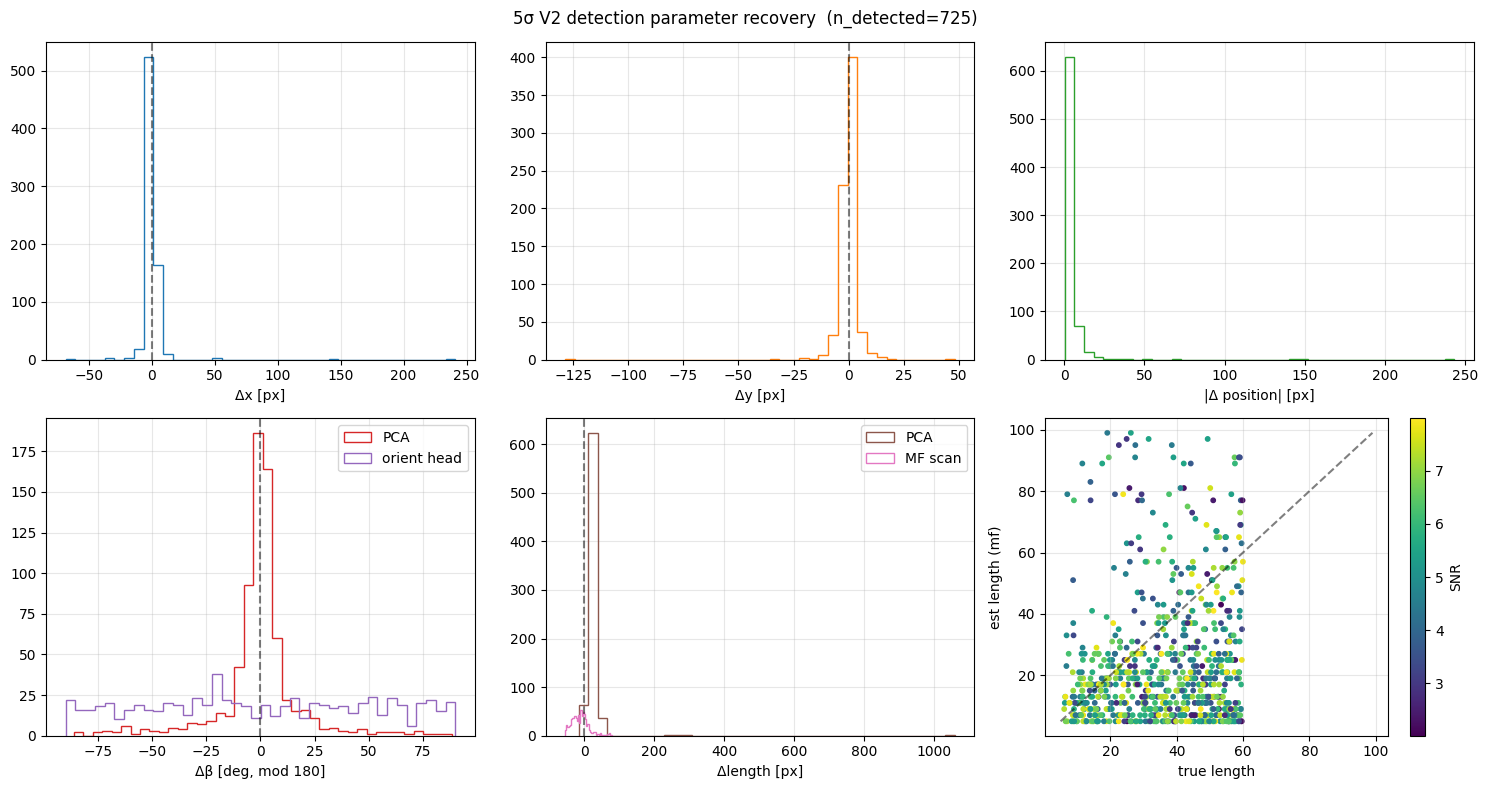

21662

In [7]:
filt = cand_df[cand_df["score_rf"] >= RF_V2_DEFAULT_THR]
matched = evaluate_parameter_recovery(
    test_catalog, filt, p,
    orient_sin=p_sin, orient_cos=p_cos,
    diffim_panels=diffim_panels, mf_length=True,
)
det = matched[matched["detected"] == True]
print(f"Detected {len(det)} / {len(matched)} catalog rows "
      f"(thr={RF_V2_DEFAULT_THR})\n")
print(summarize_residuals(matched).round(3).to_string())
plot_residuals(matched, title="5σ V2 detection parameter recovery")
plt.show()

del diffim_panels
gc.collect()

# 4 sigma threshold

_Stack-only baseline (no NN) — comparison point for the 5σ + NN result above._

In [8]:
test_h5  = "./DATA_DIFFIM/test_4sigma/test.h5"
test_csv = "./DATA_DIFFIM/test_4sigma/test.csv"

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test  = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Panels:", gt_test.shape[0])

Panels: 50


## LSST stack

Object-wise Confusion Matrix (raw stack footprints)
F1 Score: 0.0816, F2 Score: 0.1730
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               15029
Actual Positive                 318                 682



Object-wise Confusion Matrix (stack + same postprocessing as NN)
F1 Score: 0.0008, F2 Score: 0.0016
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               14568
Actual Positive                 994                   6



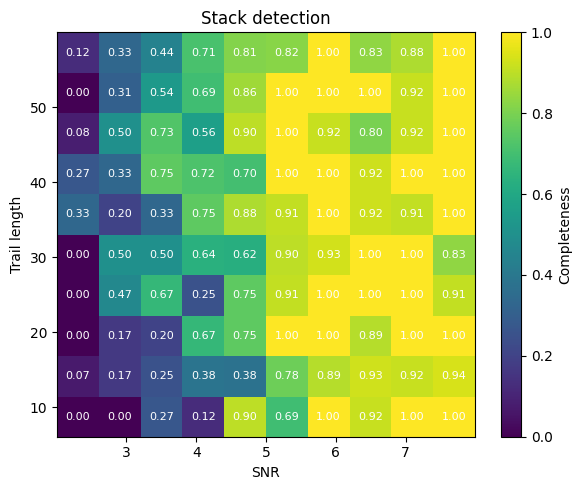

In [9]:
evals.print_confusion_matrix(get_stack_metrics(test_catalog, stack_fp), title="Object-wise Confusion Matrix (raw stack footprints)")

_, lsst_pp_cm = lsst_post_metrics(test_catalog, gt_test, stack_fp)
evals.print_confusion_matrix(lsst_pp_cm, title="Object-wise Confusion Matrix (stack + same postprocessing as NN)")

_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")
plt.show()

# 3 sigma threshold

_Stack-only baseline (no NN) — comparison point for the 5σ + NN result above._

In [10]:
test_h5  = "./DATA_DIFFIM/test_3sigma/test.h5"
test_csv = "./DATA_DIFFIM/test_3sigma/test.csv"

test_catalog = pd.read_csv(test_csv)
with h5py.File(test_h5, "r") as _f:
    gt_test  = _f["masks"][:].astype(np.uint8)
    stack_fp = _f["real_labels"][:].astype(np.uint16)
print("Panels:", gt_test.shape[0])

Panels: 50


## LSST stack

Object-wise Confusion Matrix (raw stack footprints)
F1 Score: 0.0122, F2 Score: 0.0299
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              142072
Actual Positive                 121                 879



Object-wise Confusion Matrix (stack + same postprocessing as NN)
F1 Score: 0.0012, F2 Score: 0.0030
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              126121
Actual Positive                 923                  77



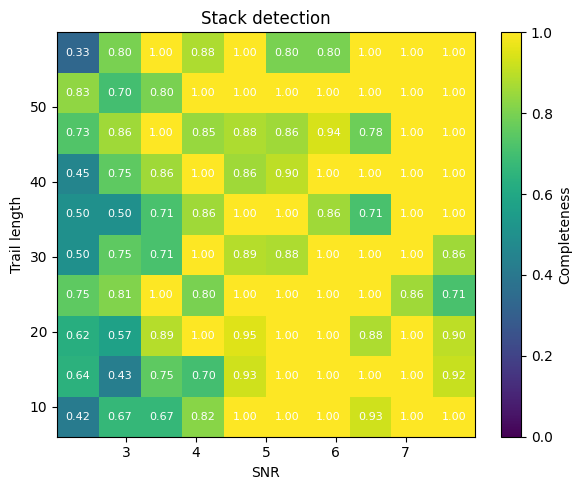

In [11]:
evals.print_confusion_matrix(get_stack_metrics(test_catalog, stack_fp), title="Object-wise Confusion Matrix (raw stack footprints)")

_, lsst_pp_cm = lsst_post_metrics(test_catalog, gt_test, stack_fp)
evals.print_confusion_matrix(lsst_pp_cm, title="Object-wise Confusion Matrix (stack + same postprocessing as NN)")

_ = evals.plot_completeness_2d(test_catalog, snr_bins=10, trail_bins=10, detected=test_catalog["stack_detection"].values.astype(bool), title="Stack detection")

# Combined

In [12]:
def plot_detect_hist(catalogs, field, labels=None, bins=12, title=None, density=False, xlim=None):
    legend = True
    if labels is None:
        labels = ["" for i in range(len(catalogs))]
        legend = False
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    for ll, cat in enumerate(catalogs):
        detected = cat[cat["stack_detection"]]
        vals = cat[field].to_numpy(); vals = vals[np.isfinite(vals)]
        if xlim is not None:
            vals = vals[(vals>=xlim[0]) & (vals<=xlim[1])]
        edges = np.histogram_bin_edges(vals, bins=bins)
        if not density:
            ax.hist(detected[field], bins=edges, histtype="step", label=labels[ll])
            ax.set_xlabel(field.replace("_"," ")); ax.set_ylabel("Count")
        else:
            all_i = np.histogram(cat[field],     bins=edges)[0]
            stk_i = np.histogram(detected[field], bins=edges)[0]
            ax.stairs(stk_i/np.maximum(all_i,1), edges, label=labels[ll])
            ax.set_xlabel(field.replace("_"," ")); ax.set_ylabel("Completeness")
    if title: ax.set_title(title)
    if legend:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return fig, ax

In [13]:
test_catalog5 = pd.read_csv("./DATA_DIFFIM/test_5sigma/test.csv")
with h5py.File("./DATA_DIFFIM/test_5sigma/test.h5", "r") as _f:
    gt_test5   = _f["masks"][:].astype(np.uint8)
    stack_fp5  = _f["real_labels"][:].astype(np.uint16)
    diffim5    = _f["images"][:].astype(np.float32)

# "5 sigma + NN" uses the SAME RF-postprocessed two-stage mask as the 5σ hero
# cell (rf_thr=RF_V2_DEFAULT_THR) — not the raw candidate mask — so every
# reported NN result in this notebook is the RF-reprocessed detector.
model = load_model(MODEL_CKPT)
p5, p5_sin, p5_cos, p5_agg = predict_panels_v7_full("./DATA_DIFFIM/test_5sigma/test.h5", model)
del model
gc.collect(); torch.cuda.empty_cache()

rf_v2 = load_rf(RF_V2_CKPT)
masks5, _, _ = two_stage_v2(
    p5, p5_sin, p5_cos, p5_agg, diffim5,
    stack_fp=stack_fp5, rf=rf_v2, rf_thr=RF_V2_DEFAULT_THR, verbose=False,
)
del rf_v2, diffim5, p5, p5_sin, p5_cos, p5_agg
gc.collect(); torch.cuda.empty_cache()
_,_, test_catalog5_nn = evals.full_confusion(catalog=test_catalog5, ground_truth=gt_test5, predictions=masks5, stack_fp=stack_fp5, threshold=MASK_THR, verbose=False)

test_catalog4 = pd.read_csv("./DATA_DIFFIM/test_4sigma/test.csv")
with h5py.File("./DATA_DIFFIM/test_4sigma/test.h5", "r") as _f:
    stack_fp4 = _f["real_labels"][:].astype(np.uint16)

test_catalog3 = pd.read_csv("./DATA_DIFFIM/test_3sigma/test.csv")
with h5py.File("./DATA_DIFFIM/test_3sigma/test.h5", "r") as _f:
    stack_fp3 = _f["real_labels"][:].astype(np.uint16)


Loaded model from: ./models/v7_diffim_scripted.pt


(<Figure size 650x450 with 1 Axes>,
 <Axes: xlabel='trail length', ylabel='Completeness'>)

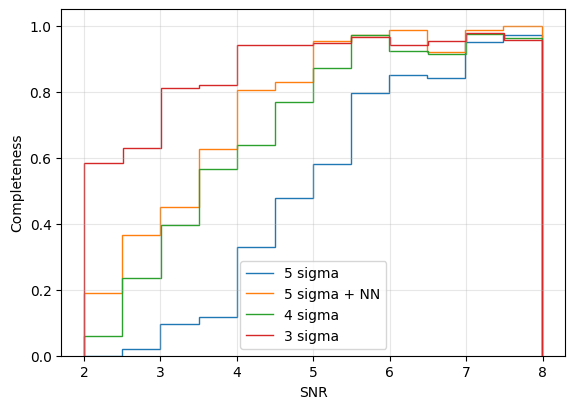

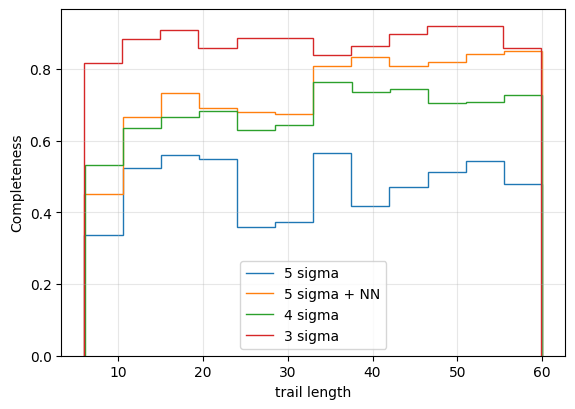

In [14]:
test_catalog5_nn["stack_detection_backup"] = test_catalog5_nn["stack_detection"]
test_catalog5_nn["stack_detection"] = test_catalog5_nn["stack_detection"] | test_catalog5_nn["nn_detected"]
plot_detect_hist([test_catalog5, test_catalog5_nn, test_catalog4, test_catalog3], "SNR",
                 labels=["5 sigma", "5 sigma + NN", "4 sigma", "3 sigma"], density=True)
plot_detect_hist([test_catalog5, test_catalog5_nn, test_catalog4, test_catalog3], "trail_length",
                 labels=["5 sigma", "5 sigma + NN", "4 sigma", "3 sigma"], density=True)